# 🍳 What Can I Cook Tonight? — End-to-End Project Showcase

> **A photo of your ingredients → the Top-5 recipes you can actually make tonight.**
> One notebook, three stages, the Bayesian model in the middle.

```
 photo ─▶ ┌─────────────┐   ┌──────────────────────┐   ┌───────────────────────────┐
          │ 1 · data    │   │ 2 · yolo             │   │ 3 · model                 │
          │ recipes_    │   │ YOLOv5 detect(image) │   │ Bayesian LDA recommender  │
          │ clean.csv   │──▶│ → ingredient labels  │──▶│ recommend(ingredients)    │──▶ Top-5
          └─────────────┘   │ → map to vocab       │   │ coverage·flavor·rating    │     recipes
                            └──────────────────────┘   └───────────────────────────┘
              data/              yolo/                       model/
                          └────────────────  run_pipeline.py  ────────────────┘
```

**What this notebook does**, every cell executed live on the real artifacts:

| § | Stage | What you'll see |
|---|-------|-----------------|
| 1 | `data/`  | The 53k-recipe Food.com corpus + a quick EDA |
| 2 | idea     | Why **recipe = document, ingredient = word, flavor = topic**, and why a *hybrid* model |
| 3 | `model/` | `train_lda`: the fitted LDA, **K-selection** by held-out perplexity, the flavor **topics** |
| 4 | `model/` | The five functions in action: `filter_candidates → infer_user_posterior → score_recipes → recommend` |
| 5 | `model/` | **Uncertainty** propagated from the φ Bootstrap into the final ranking |
| 6 | `model/` | User-facing options: `diet`, `must_use`, `diversity` (MMR) |
| 7 | `yolo/`  | **Live YOLOv5** detection on a fridge photo → ingredient labels |
| 8 | all      | The **full pipeline**: photo → detect → map → Top-5 recipes |
| 9 | —        | Honest caveats & the one-line takeaway |


## 0 · Setup

We run from the project root and point at the four pre-built artifacts (all gitignored
but present locally): the cleaned corpus, the trained LDA, the YOLO weights, and a sample
image. The model is loaded into the recommender's in-memory cache so `recommend()` never
needs to retrain.

In [1]:
import os
# torch + numpy/MKL each ship an OpenMP runtime; allow the duplicate so loading the
# YOLO detector later in the same kernel doesn't abort (standard, harmless workaround).
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import sys, json, time, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk", font_scale=0.65)

ROOT = os.getcwd()
for p in (os.path.join(ROOT, "model", "src"), os.path.join(ROOT, "yolo")):
    if p not in sys.path:
        sys.path.insert(0, p)

DATA_CSV   = os.path.join(ROOT, "data", "recipes_clean.csv")
MODEL_PKL  = os.path.join(ROOT, "model", "models", "lda_model.pkl")
WEIGHTS    = os.path.join(ROOT, "yolo", "weights", "best.pt")
SAMPLE_IMG = os.path.join(ROOT, "samples", "fridge.jpg")

import recipe_recommender as rr

print("artifact check")
for label, path in [("recipes CSV", DATA_CSV), ("LDA model", MODEL_PKL),
                    ("YOLO weights", WEIGHTS), ("sample image", SAMPLE_IMG)]:
    flag = "OK" if os.path.exists(path) else "MISSING"
    print(f"  [{flag:>7}]  {label:<13} {os.path.relpath(path, ROOT)}")

artifact check
  [     OK]  recipes CSV   data\recipes_clean.csv
  [     OK]  LDA model     model\models\lda_model.pkl
  [     OK]  YOLO weights  yolo\weights\best.pt
  [     OK]  sample image  samples\fridge.jpg


In [2]:
# Load the corpus and the trained model once; prime the recommender's cache.
df = pd.read_csv(DATA_CSV)
model = rr.load_model(MODEL_PKL)
rr._STATE = {"model": model, "df_id": id(df)}     # recommend() reuses this fit (no retrain)

print(f"Corpus : {len(df):,} recipes")
print(f"Model  : K = {model.best_k} flavor topics | vocab V = {len(model.vocab)} "
      f"ingredients | {model.n_samples} Bootstrap φ-samples")
print(f"         bootstrap_stability (mean φ std) = {model.bootstrap_stability:.2e}")

Corpus : 53,573 recipes
Model  : K = 4 flavor topics | vocab V = 500 ingredients | 50 Bootstrap φ-samples
         bootstrap_stability (mean φ std) = 4.41e-04


## 1 · Stage 1 — the recipe corpus (`data/`)

`data/prepare_data.py` downloads Food.com, keeps recipes with ≥ 5 ratings and 2–35
ingredients, runs both recipe and (later) user ingredients through the **same**
canonicalizer, and writes `recipes_clean.csv`:

`recipe_id, recipe_name, ingredients (JSON list), avg_rating, n_ratings`.

In [3]:
df.head(5)

,recipe_id,recipe_name,ingredients,avg_rating,n_ratings
0,75452,beat this banana bread,"[""sugar"", ""unsalted butter"", ""banana"", ""egg"", ...",4.4000,5
1,42198,better than sex strawberries,"[""vanilla wafer"", ""butter"", ""powdered sugar"", ...",3.8000,5
2,67547,better then bush s baked beans,"[""great northern bean"", ""chicken bouillon cube...",3.9000,10
3,63986,chicken lickin good pork chops,"[""pork chop"", ""flour"", ""salt"", ""dry mustard"", ...",4.3684,19
4,43026,chile rellenos,"[""egg roll wrap"", ""green chili"", ""cheese"", ""co...",4.0455,22


In [4]:
# Normalized ingredient lists (cached inside the recommender) drive a quick EDA.
recipe_lists = rr._get_recipe_ingredients(df)
n_ingr  = recipe_lists.map(len)
counts  = Counter()
for lst in recipe_lists:
    counts.update(lst)
top20 = counts.most_common(20)

print(f"recipes              : {len(df):,}")
print(f"distinct ingredients : {len(counts):,}")
print(f"ingredients / recipe : median {int(n_ingr.median())}, mean {n_ingr.mean():.1f}")
print(f"avg_rating           : mean {df['avg_rating'].mean():.2f} "
      f"(of {df['n_ratings'].sum():,} total ratings)")
print("top-10 ingredients   :", ", ".join(w for w, _ in top20[:10]))

recipes              : 53,573
distinct ingredients : 7,056
ingredients / recipe : median 8, mean 8.8
avg_rating           : mean 4.45 (of 811,336 total ratings)
top-10 ingredients   : salt, butter, egg, onion, flour, sugar, water, olive oil, garlic clove, milk


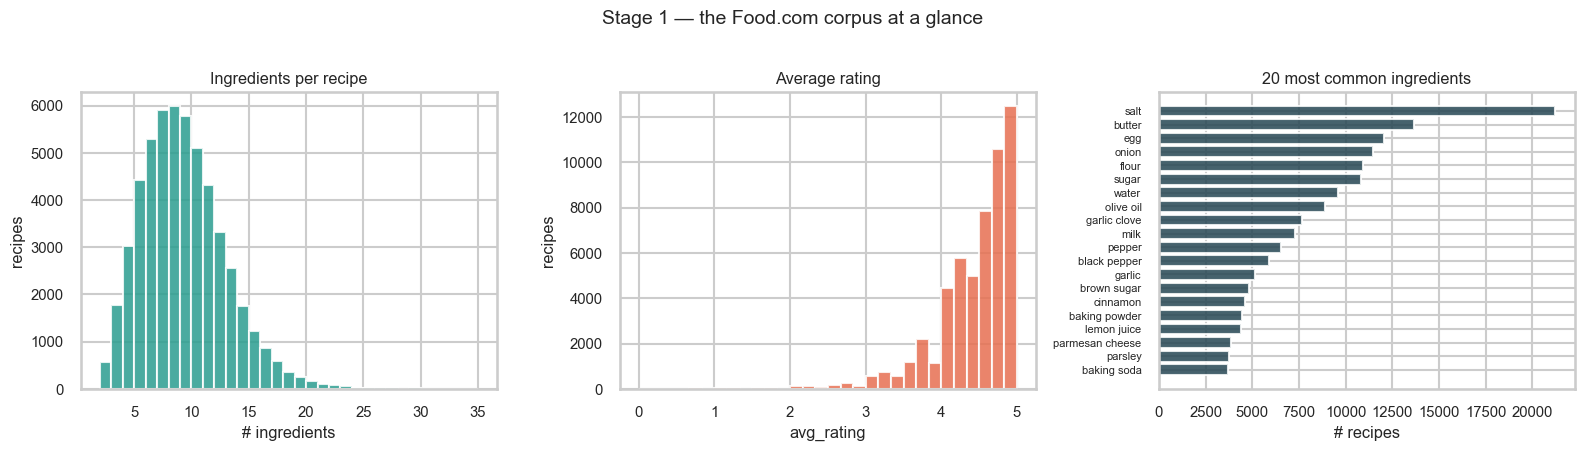

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))

ax[0].hist(n_ingr, bins=range(2, 36), color="#2a9d8f", alpha=0.85)
ax[0].set(title="Ingredients per recipe", xlabel="# ingredients", ylabel="recipes")

ax[1].hist(df["avg_rating"], bins=30, color="#e76f51", alpha=0.85)
ax[1].set(title="Average rating", xlabel="avg_rating", ylabel="recipes")

names = [w for w, _ in top20][::-1]
vals  = [c for _, c in top20][::-1]
ax[2].barh(names, vals, color="#264653", alpha=0.85)
ax[2].set(title="20 most common ingredients", xlabel="# recipes")
ax[2].tick_params(axis="y", labelsize=8)

fig.suptitle("Stage 1 — the Food.com corpus at a glance", y=1.02, fontsize=14)
fig.tight_layout(); plt.show()

## 2 · The modeling idea — and why a *hybrid*

The key analogy that lets us use **Latent Dirichlet Allocation (LDA)**:

| text LDA | this project |
|----------|--------------|
| document | a **recipe** |
| word     | an **ingredient** |
| topic    | a latent **flavor / cuisine** |

So `φ` (topic → ingredient) captures *what a flavor is made of*, and `θ` (recipe → topic)
captures *which flavors a recipe blends*. We want recommendations **with a sense of
confidence**, so uncertainty is central.

**The hard constraint.** A fully-Bayesian NUTS posterior over `φ` does **not** scale to
~50k recipes × thousands of ingredients. Our pragmatic answer:

1. Fit `φ` **once** as a sklearn point estimate `φ̂` on the **full corpus** (fast).
2. Approximate `φ`'s uncertainty by **Bootstrap** — refit on resampled recipes, keep the
   refits as pseudo-samples `phi_samples`.
3. Keep the *genuinely* Bayesian step where it matters and stays cheap: the **user's**
   topic posterior (Step 3), inferred from a handful of ingredients via Bayes' theorem
   **per φ-sample** — and propagated all the way to the score.

## 3 · Stage 3 — `train_lda()` : the fitted model

`train_lda(df) -> LDAModel`. We load the cached fit (identical to a fresh
`train_lda(df)` run, ~25–60 s) and inspect what it learned.

### 3a · How `K` is chosen — held-out perplexity
We sweep `K ∈ {4,6,8,10,12}`, training on 90% and scoring perplexity on a held-out 10%.
The **honest result**: perplexity is *monotone* in `K`, so it picks the smallest — this
corpus genuinely favors few, coarse flavor topics.

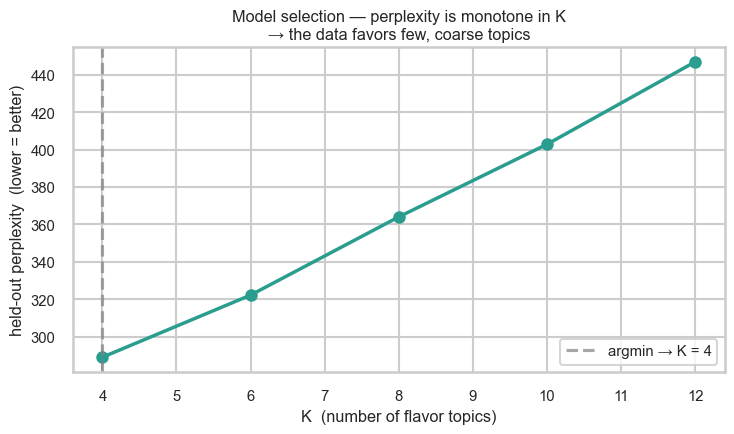

,K,holdout_perplexity
0,4,288.980046
1,6,322.219763
2,8,364.063736
3,10,402.880417
4,12,447.007017


In [6]:
perp = pd.DataFrame(json.load(open(os.path.join(ROOT, "model", "model_selection.json"))))
perp = perp.sort_values("K")
best_k = int(perp.loc[perp["holdout_perplexity"].idxmin(), "K"])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(perp["K"], perp["holdout_perplexity"], "o-", color="#2a9d8f", lw=2.5, ms=8)
ax.axvline(best_k, ls="--", color="grey", alpha=.7, label=f"argmin → K = {best_k}")
ax.set(xlabel="K  (number of flavor topics)",
       ylabel="held-out perplexity  (lower = better)",
       title="Model selection — perplexity is monotone in K\n→ the data favors few, coarse topics")
ax.legend(); fig.tight_layout(); plt.show()
perp

### 3b · The flavor topics
Each topic is summarized by its highest-probability ingredients (`topic_labels`), with
its empirical prior weight `P(topic)`.

In [7]:
topics = pd.DataFrame({
    "topic":     range(model.best_k),
    "P(topic)":  np.round(model.topic_prior, 4),
    "top ingredients (label)": model.topic_labels,
})
topics

,topic,P(topic),top ingredients (label)
0,0,0.1886,cheddar cheese / onion / green onion
1,1,0.2455,olive oil / salt / parmesan cheese
2,2,0.2280,salt / onion / water
3,3,0.3379,egg / salt / flour


### 3c · `φ` = P(ingredient | topic), with Bootstrap intervals
The point estimate `φ̂` with 94% Bootstrap intervals. The bands are **tiny** — `φ` is well
determined on 53k recipes, so we honestly call this *bootstrap stability*, not a posterior.

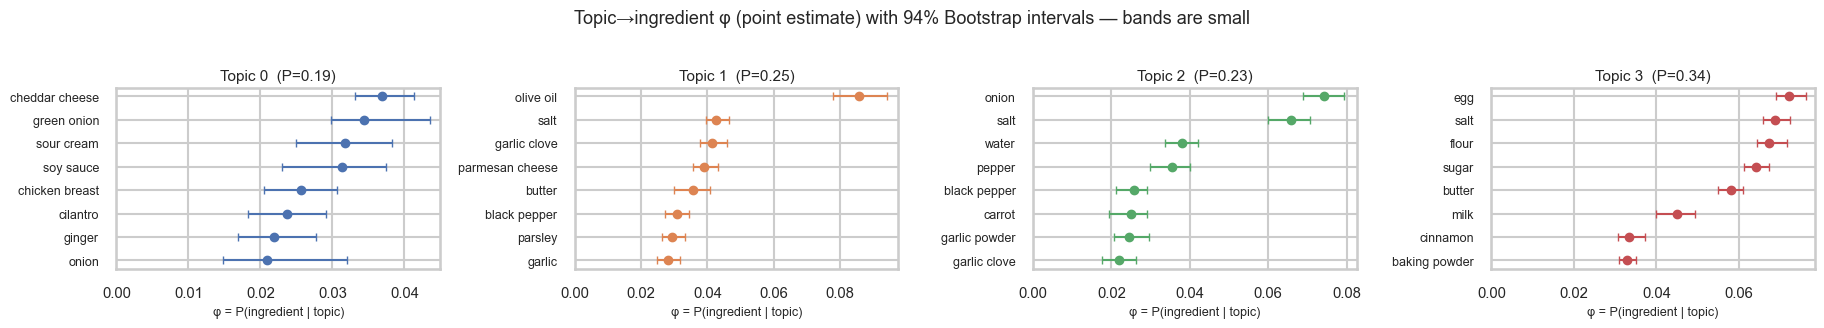

In [8]:
phi  = model.phi_samples                      # (S, K, V)
mean = phi.mean(0)
lo   = np.percentile(phi, 3,  axis=0)
hi   = np.percentile(phi, 97, axis=0)
K, top_n = model.best_k, 8

ncol = min(K, 4); nrow = int(np.ceil(K / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.6 * ncol, 3.2 * nrow))
axes = np.atleast_1d(axes).flatten()
for k in range(len(axes)):
    ax = axes[k]
    if k >= K:
        ax.axis("off"); continue
    top = np.argsort(mean[k])[::-1][:top_n]
    y = np.arange(len(top))[::-1]
    xerr = np.vstack([mean[k][top] - lo[k][top], hi[k][top] - mean[k][top]])
    ax.errorbar(mean[k][top], y, xerr=xerr, fmt="o", color=f"C{k}", capsize=3, lw=1.5, ms=6)
    ax.set_yticks(y); ax.set_yticklabels([model.vocab[i] for i in top], fontsize=9)
    ax.set_title(f"Topic {k}  (P={model.topic_prior[k]:.2f})", fontsize=11)
    ax.set_xlabel("φ = P(ingredient | topic)", fontsize=9); ax.set_xlim(left=0)
fig.suptitle("Topic→ingredient φ (point estimate) with 94% Bootstrap intervals — bands are small",
             y=1.02, fontsize=13)
fig.tight_layout(); plt.show()

## 4 · The five functions in action

We profile two pantries throughout: an **Italian-ish** one and a **Baker's** one.

In [9]:
ITALIAN = ["chicken", "garlic", "onion", "olive oil", "tomato",
           "basil", "parmesan cheese", "pasta", "salt", "pepper"]
BAKER   = ["flour", "sugar", "butter", "egg", "vanilla",
           "baking soda", "milk", "salt", "chocolate"]
print("Italian-ish :", ITALIAN)
print("Baker's     :", BAKER)

Italian-ish : ['chicken', 'garlic', 'onion', 'olive oil', 'tomato', 'basil', 'parmesan cheese', 'pasta', 'salt', 'pepper']
Baker's     : ['flour', 'sugar', 'butter', 'egg', 'vanilla', 'baking soda', 'milk', 'salt', 'chocolate']


### Step 2 · `filter_candidates()` — keep recipes you can (mostly) make
`coverage = |user ∩ recipe| / |recipe|`. Keep `coverage ≥ 0.7`; if too few survive,
relax to `0.5`.

In [10]:
cand = rr.filter_candidates(ITALIAN, df)
print(f"{len(cand):,} candidate recipes for the Italian pantry\n")
(cand.sort_values("coverage", ascending=False)
     .assign(coverage=lambda d: d["coverage"].round(2),
             matched=lambda d: d["_inter"].astype(int).astype(str) + "/" + d["_size"].astype(int).astype(str))
     [["recipe_name", "coverage", "matched", "avg_rating", "n_ratings"]]
     .head(8).reset_index(drop=True))

[filter_candidates] threshold=0.7: 53 candidate recipes
53 candidate recipes for the Italian pantry



,recipe_name,coverage,matched,avg_rating,n_ratings
0,basic confit of garlic,1.00,2/2,5.0000,5
1,blasted chicken,1.00,3/3,4.1667,6
2,crock pot roasted garlic,1.00,2/2,4.4167,12
3,simple roasted tomato and garlic sauce,1.00,3/3,3.3333,6
4,shmaltz,1.00,3/3,5.0000,5
5,tomato sandwich from italy,0.86,6/7,5.0000,9
6,tomato basil pizza sauce,0.83,5/6,4.4444,9
7,garlicky tomato bruschetta,0.83,5/6,4.7500,8


### Step 3 · `infer_user_posterior()` — the genuinely Bayesian step
Treat the ingredients as evidence and apply Bayes' theorem **per φ-sample**:

$$P(\text{topic}=k \mid \text{ingredients}) \;\propto\; \underbrace{\textstyle\prod_i \varphi_{k,i}}_{P(\text{ingredients}\mid k)} \cdot \underbrace{P(\text{topic}=k)}_{\text{empirical prior}}$$

The nice illustration: the **Italian** pantry collapses (almost) onto a single topic —
*certain* — while the **Baker's** pantry spreads across topics — *genuinely uncertain*.
Same machinery, different confidence.

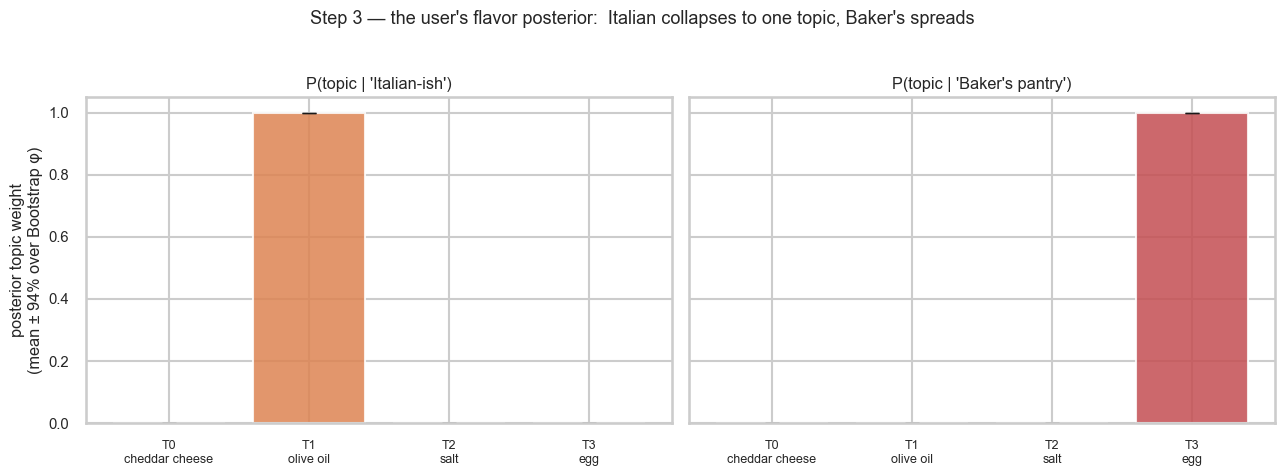

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, (name, pantry) in zip(axes, {"Italian-ish": ITALIAN, "Baker's pantry": BAKER}.items()):
    _, post = rr.infer_user_posterior(pantry, model)      # (S, K)
    m  = post.mean(0)
    err = np.vstack([np.maximum(0, m - np.percentile(post, 3, 0)),
                     np.maximum(0, np.percentile(post, 97, 0) - m)])
    x = np.arange(model.best_k)
    ax.bar(x, m, color=[f"C{k}" for k in x], alpha=0.85, yerr=err, capsize=5)
    ax.set_xticks(x)
    ax.set_xticklabels([f"T{k}\n{model.topic_labels[k].split(' / ')[0]}" for k in x], fontsize=9)
    ax.set_title(f"P(topic | '{name}')"); ax.set_ylim(0, 1.05)
axes[0].set_ylabel("posterior topic weight\n(mean ± 94% over Bootstrap φ)")
fig.suptitle("Step 3 — the user's flavor posterior:  Italian collapses to one topic, "
             "Baker's spreads", y=1.03, fontsize=13)
fig.tight_layout(); plt.show()

### Step 4 · `score_recipes()` — the composite score
$$\text{score} = \text{coverage}^2 \cdot \text{overlap\_bonus} \cdot \text{flavor\_alignment} \cdot \text{rating}$$

Each factor targets a concrete failure mode:
- **coverage²** — a dish you can't make is useless (dominant term).
- **overlap_bonus** `= 1 − e^{−|inter|/τ}` — stops a 3-ingredient dish from gaming the *ratio* to a perfect 1.0.
- **flavor_alignment** `= e^{−KL(recipe ‖ user)}` — averaged over Bootstrap φ-draws.
- **rating** — Beta-Binomial shrinkage toward the global mean for sparsely-rated dishes.

### Step 5 · `recommend()` — the Top-5

In [12]:
recs = rr.recommend(ITALIAN, df, top_n=5)
pd.DataFrame(recs)[["recipe_name", "score", "coverage", "predicted_rating",
                    "posterior_uncertainty", "flavor_tags", "missing_ingredients"]]

[filter_candidates] threshold=0.7: 53 candidate recipes


,recipe_name,score,coverage,predicted_rating,posterior_uncertainty,flavor_tags,missing_ingredients
0,tomato sandwich from italy,2.7412,6/7 ingredients,4.803,0.0,"[olive oil / salt / parmesan cheese, salt / on...",[italian bread]
1,garlicky tomato bruschetta,2.2959,5/6 ingredients,4.634,0.0,"[olive oil / salt / parmesan cheese, salt / on...",[french bread]
2,pasta with oil and garlic sauce,2.2914,5/6 ingredients,4.625,0.0,"[olive oil / salt / parmesan cheese, salt / on...",[parsley]
3,baked parmesan tomatoes,2.2415,5/6 ingredients,4.524,0.0,"[olive oil / salt / parmesan cheese, salt / on...",[oregano]
4,fresh mozzarella tomato basil salad,2.2371,5/6 ingredients,4.515,0.0,"[olive oil / salt / parmesan cheese, salt / on...",[mozzarella cheese]


In [13]:
# Score anatomy: reconstruct the four factors for the Top-5 to show the product.
mu_global = float(df["avg_rating"].mean())
_, user_post = rr.infer_user_posterior(ITALIAN, model)
by_name = {r["recipe_name"]: r for _, r in rr.filter_candidates(ITALIAN, df).iterrows()}

rows = []
for rec in recs:
    row = by_name[rec["recipe_name"]]
    _, rp   = rr.infer_user_posterior(row["_ingredients_norm"], model)
    align, _ = rr._kl_similarity(rp, user_post)
    rating  = rr._bayesian_rating(float(row["avg_rating"]), float(row["n_ratings"]), mu_global)
    cov, inter = float(row["coverage"]), float(row["_inter"])
    overlap = 1 - np.exp(-inter / rr.SCORE_TAU)
    score   = cov**rr.SCORE_ALPHA * overlap * align**rr.SCORE_BETA * rating**rr.SCORE_GAMMA
    rows.append({"recipe": rec["recipe_name"][:38],
                 "coverage^2": round(cov**2, 3), "overlap_bonus": round(overlap, 3),
                 "alignment": round(align, 3), "rating": round(rating, 3),
                 "= score": round(score, 4)})
pd.DataFrame(rows)

[filter_candidates] threshold=0.7: 53 candidate recipes


,recipe,coverage^2,overlap_bonus,alignment,rating,= score
0,tomato sandwich from italy,0.735,0.777,1.0,4.803,2.7412
1,garlicky tomato bruschetta,0.694,0.713,1.0,4.634,2.2959
2,pasta with oil and garlic sauce,0.694,0.713,1.0,4.625,2.2914
3,baked parmesan tomatoes,0.694,0.713,1.0,4.524,2.2415
4,fresh mozzarella tomato basil salad,0.694,0.713,1.0,4.515,2.2371


## 5 · Uncertainty propagated into the ranking

Because every flavor quantity is computed *per Bootstrap φ-draw*, each recommendation
carries a spread. Below is the per-draw flavor alignment for the Italian Top-5 — the φ
Bootstrap reaching the final score. (The spread is small here precisely because `φ` is
well determined; the user-side posterior in §4 is where the real uncertainty lives.)

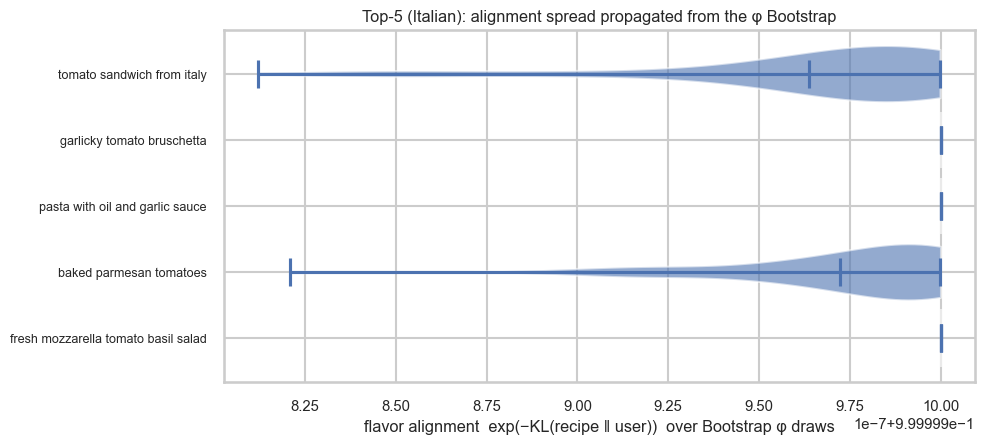

In [14]:
_EPS = 1e-12
def sim_samples(recipe_post, user_post):
    kl = np.sum(recipe_post * (np.log(recipe_post + _EPS) - np.log(user_post + _EPS)), axis=1)
    return np.exp(-kl)

sims, names = [], []
for rec in recs:
    row = by_name[rec["recipe_name"]]
    _, rp = rr.infer_user_posterior(row["_ingredients_norm"], model)
    sims.append(sim_samples(rp, user_post)); names.append(rec["recipe_name"][:42])

fig, ax = plt.subplots(figsize=(10, 4.6))
vp = ax.violinplot(sims, positions=range(len(sims)), vert=False, showmeans=True, widths=0.85)
for b in vp["bodies"]:
    b.set_alpha(0.6)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=9); ax.invert_yaxis()
ax.set_xlabel("flavor alignment  exp(−KL(recipe ‖ user))  over Bootstrap φ draws")
ax.set_title("Top-5 (Italian): alignment spread propagated from the φ Bootstrap")
fig.tight_layout(); plt.show()

## 6 · User-facing options — `diet`, `must_use`, `diversity`

`recommend()` exposes preference filters and an MMR diversity re-rank, all matched on the
same normalized tokens as coverage.

In [15]:
veg = rr.recommend(ITALIAN, df, diet="vegetarian", must_use=["tomato"], top_n=5)
print("Italian pantry — vegetarian + must use tomato:")
display(pd.DataFrame(veg)[["recipe_name", "score", "coverage", "flavor_tags"]])

div = rr.recommend(BAKER, df, diversity=0.6, top_n=5)
print("\nBaker's pantry — diversity = 0.6 (MMR re-rank for variety):")
display(pd.DataFrame(div)[["recipe_name", "score", "coverage", "flavor_tags"]])

[filter_candidates] threshold=0.7: 53 candidate recipes
[filters] diet=vegetarian, must_use=['tomato']: 53 -> 16 recipes
Italian pantry — vegetarian + must use tomato:


,recipe_name,score,coverage,flavor_tags
0,tomato sandwich from italy,2.7412,6/7 ingredients,"[olive oil / salt / parmesan cheese, salt / on..."
1,garlicky tomato bruschetta,2.2959,5/6 ingredients,"[olive oil / salt / parmesan cheese, salt / on..."
2,baked parmesan tomatoes,2.2415,5/6 ingredients,"[olive oil / salt / parmesan cheese, salt / on..."
3,fresh mozzarella tomato basil salad,2.2371,5/6 ingredients,"[olive oil / salt / parmesan cheese, salt / on..."
4,fresh tomato spaghetti sauce,2.0724,7/9 ingredients,"[olive oil / salt / parmesan cheese, salt / on..."


[filter_candidates] threshold=0.7: 725 candidate recipes

Baker's pantry — diversity = 0.6 (MMR re-rank for variety):


,recipe_name,score,coverage,flavor_tags
0,crustless baked custard pie,3.7250,7/7 ingredients,"[egg / salt / flour, olive oil / salt / parmes..."
1,self rising flour america,1.4369,3/4 ingredients,"[egg / salt / flour, salt / onion / water]"
2,amish friendship starter,2.5163,3/3 ingredients,"[egg / salt / flour, salt / onion / water]"
3,easy to make peanut butter cookies,1.2753,3/4 ingredients,"[egg / salt / flour, cheddar cheese / onion / ..."
4,crisp butter cookies refrigerator cookies,2.3722,5/6 ingredients,"[egg / salt / flour, salt / onion / water]"


## 7 · Stage 2 — from a *photo* (`yolo/`)  ·  live detection

The front door of the product: a trained **YOLOv5** detector (`weights/best.pt`, 95
ingredient classes) finds raw ingredients in an image. We load it through the cloned
`ultralytics/yolov5` repo (a one-time `torch.hub.load`), run it on a fridge photo, and
draw the detections.

In [16]:
import detect as yolo_detect
import yolo_mapping

t0 = time.time()
det_model = yolo_detect.load_detector(WEIGHTS)
det_model.conf = 0.25
print(f"detector loaded in {time.time() - t0:.1f}s  ·  "
      f"{len(yolo_detect.class_names(WEIGHTS))} ingredient classes")

YOLOv5  70b964b Python-3.13.5 torch-2.12.0.dev20260314+cu128 CUDA:0 (NVIDIA GeForce RTX 5090 Laptop GPU, 24463MiB)



Fusing layers... 


Model summary: 212 layers, 21232788 parameters, 0 gradients, 49.1 GFLOPs


Adding AutoShape... 


YOLOv5  70b964b Python-3.13.5 torch-2.12.0.dev20260314+cu128 CUDA:0 (NVIDIA GeForce RTX 5090 Laptop GPU, 24463MiB)



Fusing layers... 


Model summary: 212 layers, 21232788 parameters, 0 gradients, 49.1 GFLOPs


Adding AutoShape... 


detector loaded in 5.2s  ·  95 ingredient classes


YOLOv5 detections on samples/fridge.jpg:


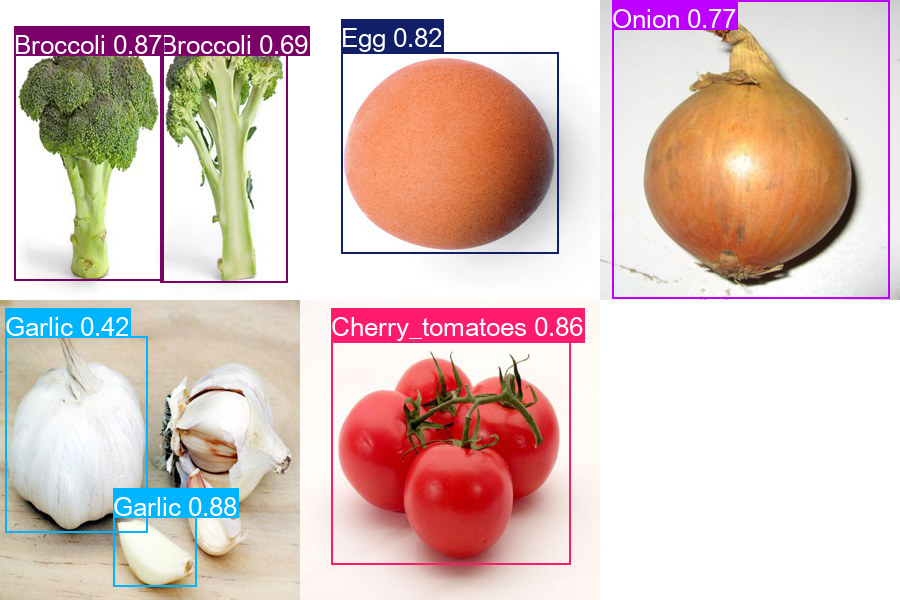

In [17]:
# Draw the detections and embed the annotated image straight from bytes via PIL —
# we avoid matplotlib here so it never collides with torch's OpenMP runtime.
import io
from PIL import Image as PILImage
from IPython.display import Image as IPyImage, display

results = det_model(SAMPLE_IMG)
results.render()                                    # boxes drawn onto results.ims
imgs = getattr(results, "ims", None) or getattr(results, "imgs")
buf = io.BytesIO(); PILImage.fromarray(imgs[0]).save(buf, format="PNG")
print("YOLOv5 detections on samples/fridge.jpg:")
display(IPyImage(data=buf.getvalue(), format="png"))

In [18]:
detections  = yolo_detect.detect(SAMPLE_IMG, weights=WEIGHTS, conf=0.25)
ingredients = yolo_mapping.map_labels(detections)
print("raw YOLO detections (label, confidence):")
for label, c in detections:
    print(f"  {c:5.2f}  {label}")
print("\n→ mapped to canonical recipe ingredients:")
print(" ", ingredients)

raw YOLO detections (label, confidence):
   0.88  Garlic
   0.87  Broccoli
   0.86  Cherry_tomatoes
   0.82  Egg
   0.77  Onion

→ mapped to canonical recipe ingredients:
  ['garlic', 'broccoli', 'cherry tomato', 'egg', 'onion']


## 8 · The full pipeline — photo → Top-5 recipes

`run_pipeline.run(image)` wires the three stages together: **detect** (Stage 2) → **map**
(Stage 2) → **recommend** (Stage 3). One call, a real image, the recipes you can cook.

In [19]:
import run_pipeline

detections, ingredients, recs = run_pipeline.run(SAMPLE_IMG, top_n=5)
print("detected :", [d[0] for d in detections])
print("mapped   :", ingredients, "\n")
pd.DataFrame(recs)[["recipe_name", "score", "coverage", "predicted_rating", "flavor_tags"]]

[filter_candidates] threshold=0.5: 25 candidate recipes
detected : ['Garlic', 'Broccoli', 'Cherry_tomatoes', 'Egg', 'Onion']
mapped   : ['garlic', 'broccoli', 'cherry tomato', 'egg', 'onion'] 



,recipe_name,score,coverage,predicted_rating,flavor_tags
0,italian spinach,0.3228,2/4 ingredients,4.603,"[olive oil / salt / parmesan cheese, cheddar c..."
1,broccoli with browned butter,0.2839,2/4 ingredients,4.424,"[olive oil / salt / parmesan cheese, cheddar c..."
2,fried eggs with onion ukrainian russian,0.2720,2/4 ingredients,4.788,"[olive oil / salt / parmesan cheese, cheddar c..."
3,potato and onion tortilla,0.2461,2/4 ingredients,4.412,"[olive oil / salt / parmesan cheese, salt / on..."
4,basic confit of garlic,0.1468,1/2 ingredients,4.724,"[olive oil / salt / parmesan cheese, salt / on..."


And a second image — a pile of mixed vegetables — to show it generalizes.

In [20]:
IMG2 = os.path.join(ROOT, "samples", "vegetables.jpg")
det2, ingr2, recs2 = run_pipeline.run(IMG2, top_n=5)
print("detected :", [d[0] for d in det2])
print("mapped   :", ingr2, "\n")
pd.DataFrame(recs2)[["recipe_name", "score", "coverage", "predicted_rating", "flavor_tags"]] \
    if recs2 else "no confident detections — try a clearer photo / lower --conf" 

[filter_candidates] threshold=0.5: 18 candidate recipes
detected : ['Carrot', 'Cherry_tomatoes', 'Garlic', 'Broccoli', 'Lemon', 'Onion']
mapped   : ['carrot', 'cherry tomato', 'garlic', 'broccoli', 'lemon', 'onion'] 



,recipe_name,score,coverage,predicted_rating,flavor_tags
0,broccoli cauliflower with garlic lemon italy,0.6996,3/5 ingredients,4.711,"[olive oil / salt / parmesan cheese, salt / on..."
1,lemon roasted onions carrots,0.5353,3/6 ingredients,4.520,"[olive oil / salt / parmesan cheese, salt / on..."
2,greek marinade for shrimp seafood,0.4205,2/4 ingredients,4.770,"[olive oil / salt / parmesan cheese, salt / on..."
3,steamed asparagus with lemon,0.2267,1/2 ingredients,4.557,"[olive oil / salt / parmesan cheese, cheddar c..."
4,braised leeks,0.2020,2/4 ingredients,4.543,"[olive oil / salt / parmesan cheese, salt / on..."


## 9 · Honest caveats & takeaway

- **`φ` is a point estimate (the core trade).** Full NUTS doesn't scale to ~50k recipes,
  so `φ` is fit once with sklearn and its uncertainty is *approximated* by Bootstrap. The
  spread is **stability**, not a true posterior, and is small *by design* at this scale —
  `posterior_uncertainty ≈ 0`. The uncertainty that matters is the **user's** topic
  posterior (§4), which stays fully Bayesian.
- **`K = 4` is the data's choice.** Held-out perplexity is monotone in `K` here, so coarse
  flavor tags are the honest default. `K` is a one-line override; recommendations are
  robust to it because coverage and rating dominate the score.
- **Label alignment matters.** Each Bootstrap refit's topics are arbitrarily ordered;
  the Hungarian algorithm (`topic_alignment.align_phi`) realigns them so `phi_samples[:, k, :]`
  is a coherent "topic k" across draws — which is what makes the KL meaningful.

**In one line:** an everyday question turned into a *methodologically honest* system — `φ`
as a point estimate to buy full-corpus scale and speed, uncertainty approximated by
Bootstrap, and the real Bayesian fidelity kept where it belongs: the user posterior
inferred from a few ingredients, carried all the way to every recommendation — and now
reachable straight from a **photo**. 🍳